In [1]:
#other imports
import os
import numpy as np
os.chdir('C:/Code/Github/GLM-analysis/')

In [2]:
from DataHandlerDecoding import DataHandlerDecoding as datafun
from Plotter import Plotter as plotterfun
from DecoderAnalyzer import DecoderAnalyzer as analysisdec

In [3]:
#initialize class
# decoded_variables= {'sound_category', 'choice', 'photostim', 'outcome','shuffled/sound_category', 'shuffled/choice', 'shuffled/photostim', 'shuffled/outcome'}
decoded_variables= { 'photostim', 'shuffled/photostim'}

data_handler = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed

In [4]:
# LOAD INFO ABOUT DATASETS
info_dir = 'V:/Connie/results/opto_2024/context/mod'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)
# for dat in datasets:
#     print(dat)

# Indices to remove (example: remove datasets at indices 0 and 2)
#remove_indices = [0,2,3,4,5,6,7,8,9,10,11,12,13,15,16,18,19,20,21,22]
#remove_indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]
#remove_indices = [0,2,3,6,8,9,10,11,12,13,15,16,18,19,20,21,22,23,24]
#remove_indices = [0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] #1
#remove_indices = [0,1,2,6,8,9,10,11,16,19,22,24] #7 no outcome
remove_indices = [0,1,2,4,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]

# Remove indices from both lists
datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]
for dat in datasets:
    print(dat)

('HA2-1L', '2023-05-05', 'V:')
('HA1-00', '2023-08-28', 'W:')


In [5]:
#LOAD ACTUAL DATASETS 
save_results = os.path.join(f'V:/Connie/results/glm_decoding/prelim')
os.makedirs(save_results, exist_ok=True)
cat_results = []

model_type = 'GLM_3nmf_pre'
#results_pre,results_pre_all = data_handler.process_multiple_datasets(datasets, model_type)
# results_pre,results_pre_all_sb, cat_results, celltype_info = data_handler.process_multiple_datasets(datasets, model_type,single_balanced=True) 

# results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives means across sc or pop
# results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives each split!

model_type = 'GLM_3nmf_passive'
#results_pass,results_pass_all = data_handler.process_multiple_datasets(datasets, model_type)
results_pass,results_pass_all_sb, cat_results, celltype_info = data_handler.process_multiple_datasets(datasets, model_type,single_balanced=True) 

Processing dataset: HA2-1L_2023-05-05
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/1_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/2_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/3_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/4_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/5_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/6_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/dec

In [6]:
#Initialize plotting class

# Define colors dictionary
colors_dict = {
    'pyr': (0.37, 0.75, 0.49), 
    'som': (0.17, 0.35, 0.8), 
    'pv': (0.82, 0.04, 0.04)
}

plotter = plotterfun(data = None,celltypecolors=colors_dict, save_results= save_results)

In [7]:
# for dataset in results_pre_all_sb:
#     print(dataset)
#     print(np.shape(results_pre_all_sb[dataset]['photostim']['sc_cumulative_information_mean']))

# del results_pre_all_sb['HE1-00_2023-05-30']

#np.shape(results_pass_all_sb['HE1-00_2023-05-30']['shuffled/sound_category']['sc_cumulative_information_mean'])
# for dataset in results_pre_all_sb:
#     print(np.shape(cat_results[dataset]['shuffled/sound_category'][2]['sc_cumulative_information']))
# del cat_results['HE4-1L1R_2023-08-21']

In [8]:
# Get shuffled data into frames x neurons x total shuffles across splits (50 * 10 = 500)

shuffled_structure = data_handler.create_shuffled_distribution_structure(decoder_type = 'photostim', metric = 'sc_instantaneous_information')

HA2-1L_2023-05-05
HA1-00_2023-08-28


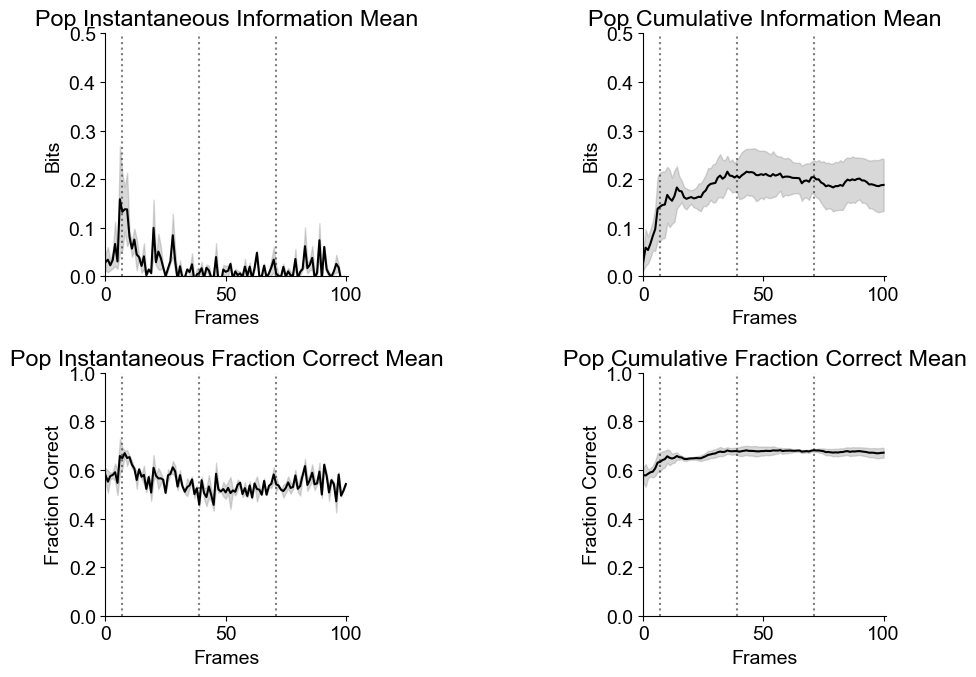

In [9]:
# Plot population decoders across datasets
results_pre_all = results_pass_all_sb 
current_decoder_type = 'photostim'   
# Usage example:
plotter.plot_decoding_results(results_pre_all, 
                     decoder_type= current_decoder_type,
                     plot_type='pop',
                     save_dir=plotter.save_results,
                     #xlim = (0,100),
                     ylim = [0.5, 0.5, 1, 1]) 

In [10]:
# Create an instance of AnalysisManager, passing in the plotter module
analysis_dec = analysisdec(celltype_info)

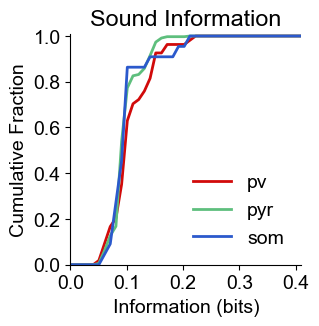

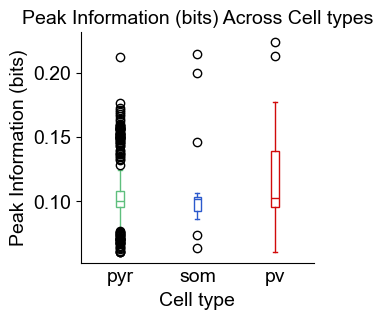

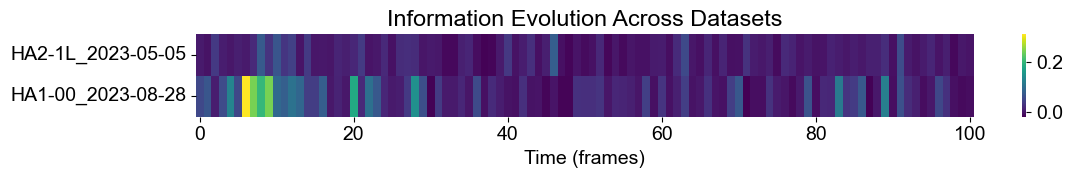

In [18]:
#DECIDE WHETHER OR NOT TO USE END FRAME
peaks_by_celltype = analysis_dec.analyze_peaks_by_celltype( results_pre_all,shuffled_structure,
                                                            decoder_type=current_decoder_type, start_frame=14, end_frame = 100,
                                                            significance_percentile = 95, threshold = None) #, end_frame = 100

#PLOT DISTRIBUTIONS OF SIGINIFICANT NEURONS!
metric_to_plot = 'sc_instantaneous_information_mean'
cdf_data, cell_labels = analysis_dec.format_peaks_for_cdf(peaks_by_celltype,metric = metric_to_plot, significant_only=True)
all_peaks, neuron_groups = analysis_dec.format_peaks_for_boxplot(peaks_by_celltype, metric = metric_to_plot, significant_only=True)

#cdf
plotter.plot_cdf_coupling_index(np.array(cdf_data['all']['peaks']),
                                cell_labels,
                                colors = plotter.celltypecolors,
                                title='Sound Information',
                                xlabel = 'Information (bits)',
                                xval=.4,
                                xint=0.1)

#make boxplot!
plotter.box_plot(
    data=all_peaks,
    neuron_groups=neuron_groups,
    colors=plotter.celltypecolors,
    measure_string='Peak Information (bits)'
)

#heatmap across datasets
plotter.plot_decoding_heatmap_datasets(results_pre_all, decoder_type= current_decoder_type, metric = 'pop_instantaneous_information_mean')

In [12]:
def visualize_single_neuron_analysis(results_dict,shuffled_structure , plotter, analyzer, decoder_type='sound_category', start_frame=14, end_frame=None, metric = 'sc_instantaneous_information_mean', significance_percentile = 95, threshold = None):
    """Orchestrate single neuron analysis and visualization."""

    significant_neurons_data, significance_struc = analyzer.analyze_significant_neurons(results_dict,shuffled_structure, decoder_type, start_frame, end_frame,metric ,significance_percentile)
    
    #using threshold to get significant neurons? threshold_value = 0.06
    if threshold is not None:
        significant_neurons_data, significance_struc = analyzer.analyze_significant_neurons_by_threshold(results_dict, decoder_type, start_frame, end_frame,metric,threshold)
    
    # Extract significant neurons for each dataset
    significant_neurons = {dataset: np.concatenate([significant_neurons_data[dataset][celltype] for celltype in significant_neurons_data[dataset]]) 
                           for dataset in significant_neurons_data}
    
    # Plot the heatmap, only using significant neurons if they exist
    #plotter.plot_neuron_performance_heatmap(results_dict, decoder_type, start_frame, end_frame, metric, significant_neurons) #separated by datasets

    plotter.plot_significant_neurons_distribution(significance_struc) 

    plotter.plot_time_course_by_cell_type(results_dict, decoder_type, start_frame = 0, end_frame = end_frame, metric = metric)

    plotter.plot_summary_heatmap(results_dict, decoder_type, start_frame, end_frame, metric, significant_neurons) #combined across datasets


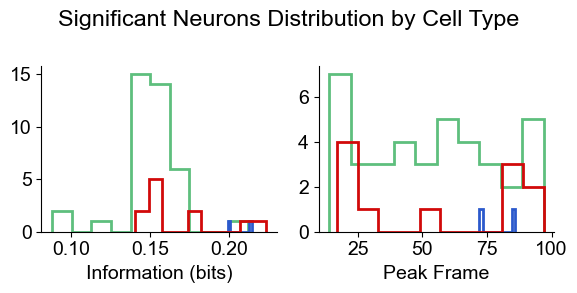

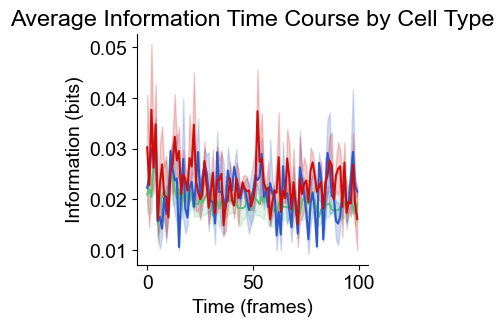

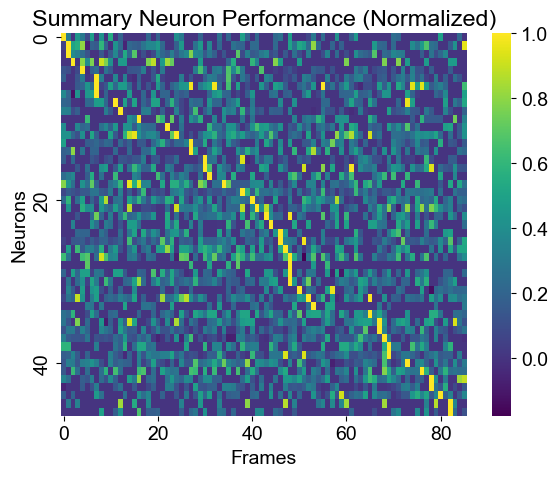

In [19]:
# Call the visualization function
visualize_single_neuron_analysis(
    results_dict=results_pre_all,
    shuffled_structure = shuffled_structure,
    plotter=plotter,
    analyzer =analysis_dec,
    decoder_type = current_decoder_type,  # Or your preferred decoder type
    start_frame = 14,                 # Specify start frame
    end_frame = 100,                    # Specify end frame if needed, else None
    metric = 'sc_instantaneous_information_mean', #choose sc metric to look at
    significance_percentile = 95,         #used to determine significant cells
    threshold = None                   #None or 0.06 (from Runyan 2017)
)